Sample rate: 22050 Hz
Samples: 105507
Duration: 4.785 s

Fourier approximation:
v(t) = 0.1169*cos(2π*213.2*t + -0.9818) + 0.1398*cos(2π*213.8*t + -1.0635) + 0.1397*cos(2π*214.4*t + -1.0706) + 0.1288*cos(2π*215.1*t + -0.9406) + 0.1122*cos(2π*215.7*t + -0.8452) + 0.1167*cos(2π*343.2*t + 0.5487) + 0.1205*cos(2π*344.2*t + 3.1374) + 0.1683*cos(2π*345.5*t + 0.2546) + 0.0320

Band detected: True
Threshold: 0.0016 V
Energy value detected: 0.0105 V
Duty cycle: 0.32%


/var/folders/wn/3w4qxxnj6ml45c3mrvwn97qc0000gn/T/ipykernel_27869/730879951.py:18: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, signal = wavfile.read(wav_file)


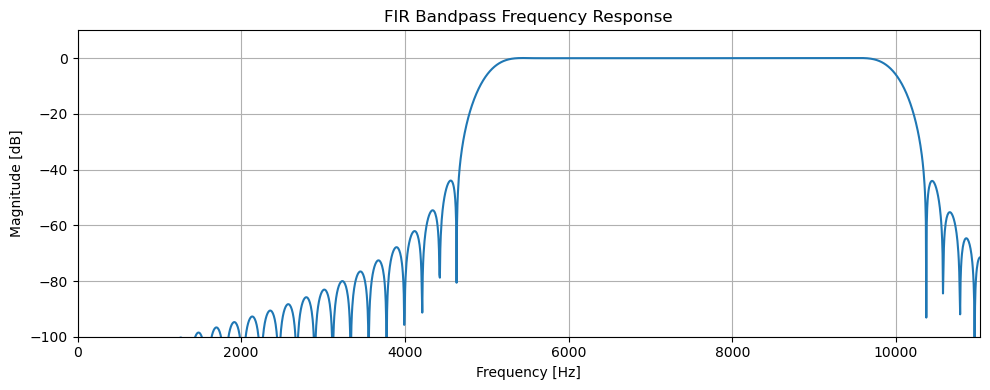

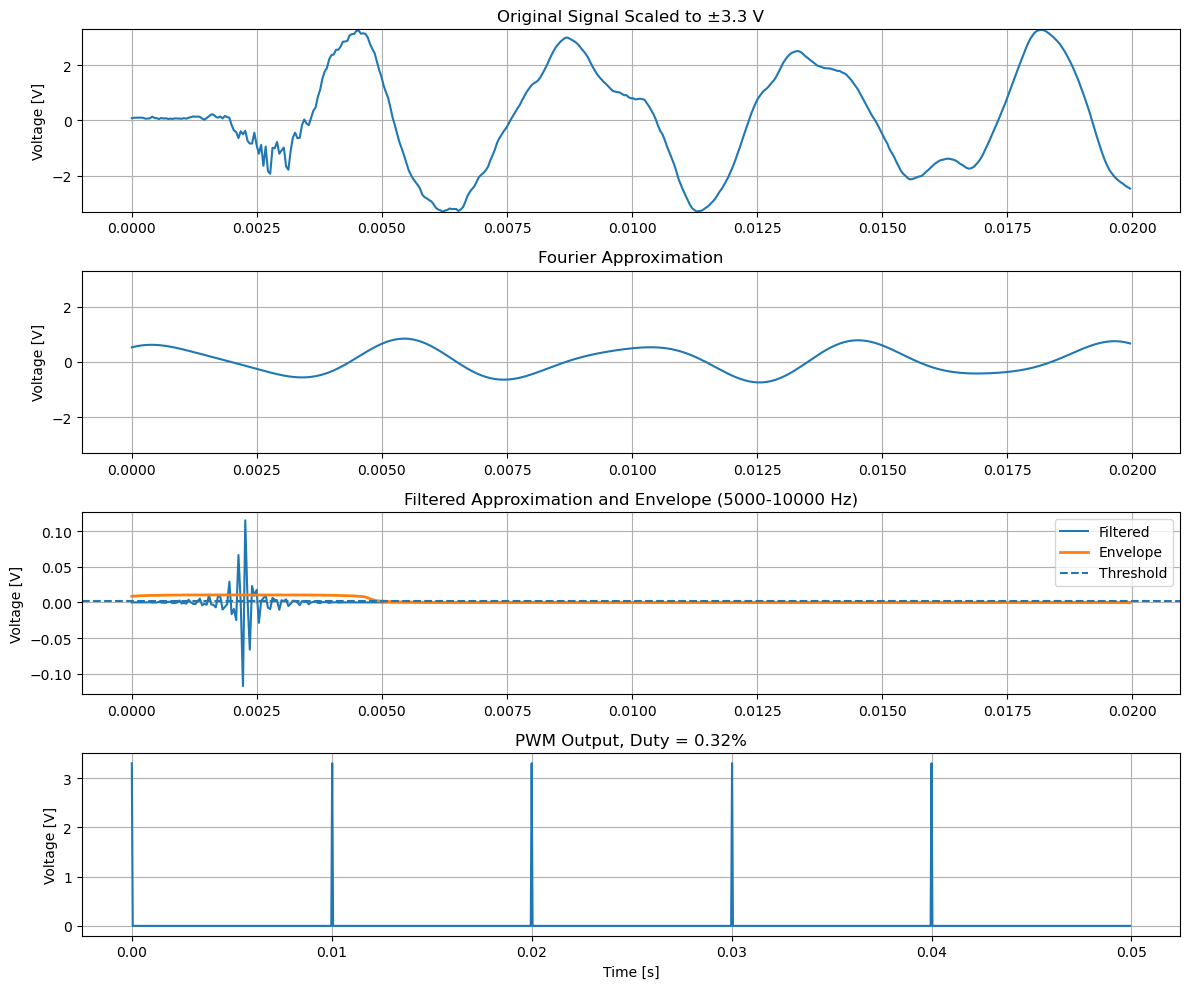

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import firwin, lfilter, hilbert, freqz

def project_pipeline_software(
    wav_file,
    low_freq,
    high_freq,
    num_sines=8,
    pwm_freq=100,              # Hz
    pwm_duration=1.0,          # time to display
    max_voltage=3.3,
    numtaps=101,
    detection_ratio=0.15
):

    fs, signal = wavfile.read(wav_file)

    if len(signal.shape) > 1:
        signal = signal.mean(axis=1)

    signal = signal.astype(np.float64)

    # Scale original signal so max magnitude maps properly
    peak = np.max(np.abs(signal))
    if peak == 0:
        raise ValueError("Input signal is all zeros.")
    signal_volts = (signal / peak) * max_voltage

    N = len(signal_volts)
    t = np.arange(N) / fs

    print(f"Sample rate: {fs} Hz")
    print(f"Samples: {N}")
    print(f"Duration: {N/fs:.3f} s")


    # Fourier approximation of WAV

    fft_vals = np.fft.rfft(signal_volts)
    fft_freqs = np.fft.rfftfreq(N, d=1/fs)

    magnitudes = np.abs(fft_vals)
    magnitudes[0] = 0  # ignore DC when choosing tones

    top_indices = np.argsort(magnitudes)[-num_sines:]
    top_indices = top_indices[np.argsort(fft_freqs[top_indices])]

    approx_signal = np.zeros_like(signal_volts)
    terms = []

    for idx in top_indices:
        freq = fft_freqs[idx]
        amplitude = 2 * np.abs(fft_vals[idx]) / N   # Vpeak
        phase = np.angle(fft_vals[idx])

        approx_signal += amplitude * np.cos(2 * np.pi * freq * t + phase)
        terms.append((amplitude, freq, phase))

    dc_offset = np.mean(signal_volts)
    approx_signal += dc_offset

    # Hard clamp to physical rail limits just in case
    approx_signal = np.clip(approx_signal, -max_voltage, max_voltage)

    print("\nFourier approximation:")
    eq = "v(t) = " + " + ".join(
        [f"{A:.4f}*cos(2π*{f:.1f}*t + {phi:.4f})" for A, f, phi in terms]
    )
    eq += f" + {dc_offset:.4f}"
    print(eq)


    # FIR bandpass on approximated signal 
    band = [low_freq, high_freq]
    taps = firwin(numtaps, band, window='hann', pass_zero=False, fs=fs)

    filtered_signal = lfilter(taps, 1, approx_signal)

    
    # Envelope detector
    analytic_signal = hilbert(filtered_signal)
    envelope = np.abs(analytic_signal)
    smooth_window_ms = 5
    smooth_window_samples = max(1, int(fs * smooth_window_ms / 1000))
    kernel = np.ones(smooth_window_samples) / smooth_window_samples
    envelope_smooth = np.convolve(envelope, kernel, mode='same')


    # Band detection
    threshold = detection_ratio * np.max(envelope_smooth)
    band_present_mask = envelope_smooth > threshold
    band_detected = np.any(band_present_mask)

    if band_detected:
        energy_value = np.max(envelope_smooth)
    else:
        energy_value = 0.0

    
    energy_value = min(max(energy_value, 0.0), max_voltage) # Clamp energy to 0..max_voltage for duty cylce

  
    duty_cycle = energy_value / max_voltage   # 0 to 1
    duty_cycle = np.clip(duty_cycle, 0.0, 1.0)

    print(f"\nBand detected: {band_detected}")
    print(f"Threshold: {threshold:.4f} V")
    print(f"Energy value detected: {energy_value:.4f} V")
    print(f"Duty cycle: {duty_cycle*100:.2f}%")

    
    # Generate fixed-duty PWM at 0 to 3.3V
    pwm_t = np.arange(int(fs * pwm_duration)) / fs
    pwm_period = 1.0 / pwm_freq
    pwm_phase = np.mod(pwm_t, pwm_period) / pwm_period

    if band_detected:
        pwm_signal = np.where(pwm_phase < duty_cycle, max_voltage, 0.0)
    else:
        pwm_signal = np.zeros_like(pwm_t)

    
    
    # FIR response
    w, h = freqz(taps, 1, worN=2000, fs=fs)
    plt.figure(figsize=(10, 4))
    plt.plot(w, 20 * np.log10(np.abs(h) + 1e-12))
    plt.title("FIR Bandpass Frequency Response")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude [dB]")
    plt.xlim([0, fs/2])
    plt.ylim([-100, 10])
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Main signal
    plot_samples = min(int(0.02 * fs), N)

    plt.figure(figsize=(12, 10))

    plt.subplot(4, 1, 1)
    plt.plot(t[:plot_samples], signal_volts[:plot_samples])
    plt.title("Original Signal Scaled to ±3.3 V")
    plt.ylabel("Voltage [V]")
    plt.ylim([-3.3, 3.3])
    plt.grid(True)

    plt.subplot(4, 1, 2)
    plt.plot(t[:plot_samples], approx_signal[:plot_samples])
    plt.title("Fourier Approximation")
    plt.ylabel("Voltage [V]")
    plt.ylim([-3.3, 3.3])
    plt.grid(True)

    plt.subplot(4, 1, 3)
    plt.plot(t[:plot_samples], filtered_signal[:plot_samples], label="Filtered")
    plt.plot(t[:plot_samples], envelope_smooth[:plot_samples], label="Envelope", linewidth=2)
    plt.axhline(threshold, linestyle='--', label="Threshold")
    plt.title(f"Filtered Approximation and Envelope ({low_freq}-{high_freq} Hz)")
    plt.ylabel("Voltage [V]")
    plt.legend()
    plt.grid(True)

    plt.subplot(4, 1, 4)
    pwm_plot_samples = min(int(0.05 * fs), len(pwm_t))
    plt.plot(pwm_t[:pwm_plot_samples], pwm_signal[:pwm_plot_samples])
    plt.title(f"PWM Output, Duty = {duty_cycle*100:.2f}%")
    plt.xlabel("Time [s]")
    plt.ylabel("Voltage [V]")
    plt.ylim([-0.2, 3.5])
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return {
        "fs": fs,
        "original_signal_volts": signal_volts,
        "approx_signal": approx_signal,
        "filtered_signal": filtered_signal,
        "envelope": envelope_smooth,
        "band_detected": band_detected,
        "energy_value": energy_value,
        "duty_cycle": duty_cycle,
        "pwm_time": pwm_t,
        "pwm_signal": pwm_signal,
        "terms": terms,
        "taps": taps
    }

#function call
results = project_pipeline_software(wav_file="drmapan.wav",low_freq=5000,
    high_freq=10000,
    num_sines=8,
    pwm_freq=100,
    pwm_duration=1.0,
    max_voltage=3.3)